In [ ]:
import sys
import os
sys.path.append("C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.7\\bin\\")
sys.path.append("C:\\Users\\SMest\\Dropbox\\scratch_space\\llm_test")
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction
from joblib import dump, load
import numpy as np
from torch.utils.data import Dataset
import torch
import matplotlib.pyplot as plt
from nnDS import nnDS, nnCorrTokenizer
#get multi dimensional scaling
from sklearn.manifold import MDS
print(torch.cuda.is_available())


c:\Users\SMest\miniconda3\envs\transformers\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

data = nnDS( "nn_ds_c.joblib","nn_ds.joblib", 512, 512, 7 )

#make a corrleation tokenizer
tokenizer = nnCorrTokenizer( n_tokens=5048, data=data,)

#replace the tokenizer in the model
data.tokenizer = tokenizer



Computing correlation matrix
Clustering


it: 0, stress 36760.65969779695
it: 1, stress 23532.35186880584
it: 2, stress 23356.018903541175
it: 3, stress 23281.831713161657
it: 4, stress 23244.05278770658
it: 5, stress 23221.98862921277
it: 6, stress 23207.29817459424
it: 7, stress 23196.204268056103
it: 8, stress 23186.849262607444
it: 9, stress 23178.27624586518
it: 10, stress 23169.97700703913
it: 11, stress 23161.732008209194
it: 12, stress 23153.506726115123
it: 13, stress 23145.304328202677
it: 14, stress 23137.03468842772
it: 15, stress 23128.54929702584
it: 16, stress 23119.89168811555
it: 17, stress 23110.981133788966
it: 18, stress 23101.889835811395
it: 19, stress 23092.55428432152
it: 20, stress 23083.028112397078
it: 21, stress 23073.326952715484
it: 22, stress 23063.445616779354
it: 23, stress 23053.53851823339
it: 24, stress 23043.54927990755
it: 25, stress 23033.447891373176
it: 26, stress 23023.152713415388
it: 27, stress 23012.363152095822
it: 28, stress 23001.266716548693
it: 29, stress 22990.032773459316
it:

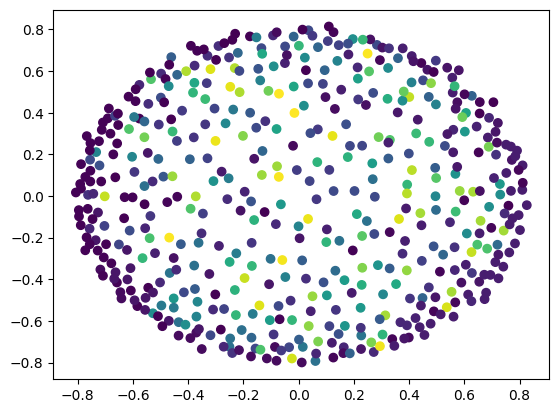

In [3]:
#run MDS on the data
mds = MDS(n_components=2, dissimilarity='precomputed', verbose=2)
mds_data = mds.fit_transform(tokenizer.corr[::10, ::10])

#plot the data
plt.scatter(mds_data[:,0], mds_data[:,1], c=tokenizer.sample_tokens[::10])
plt.show()

In [6]:
import umap
reducer = umap.UMAP(metric='precomputed')
embedding = reducer.fit_transform(tokenizer.corr)


c:\Users\SMest\miniconda3\envs\transformers\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\SMest\miniconda3\envs\transformers\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


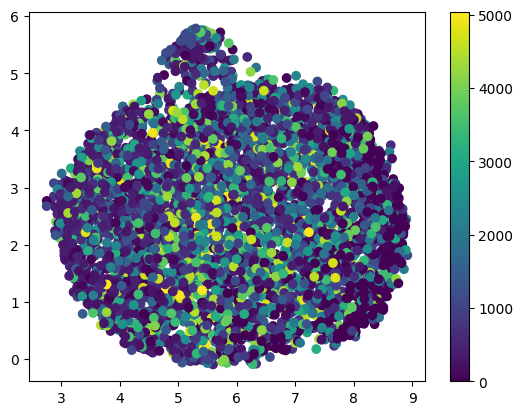

In [8]:
plt.scatter(embedding[:,0], embedding[:,1], c=tokenizer.sample_tokens)
plt.colorbar()